In [24]:
import string
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def print_binary_metrics(tp, fn, fp, tn):
    """Calculates and prints classification metrics for binary confusion matrix."""
    accuracy = (tp + tn) / (tp + fn + fp + tn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Also known as Recall / TPR
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Also known as TNR
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    print("\n--- Classification Metrics ---")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Sensitivity: {sensitivity:.4f} (Recall)")
    print(f"Specificity: {specificity:.4f}")
    print(f"NPV:         {npv:.4f}")

def create_mock_classification_problem(
    n_classes=2, 
    n_samples=500, 
    n_features=20, 
    random_state=15, 
    custom_matrix=None, 
    display_labels=None
):
    """
    Creates or accepts a confusion matrix, plots it, and prints performance metrics.
    
    Parameters:
    - custom_matrix: np.ndarray / list (2D), optional custom confusion matrix to plot directly.
    - display_labels: list, optional labels for custom_matrix axes.
    """
    fig, ax = plt.subplots(figsize=(6, 5))

    # --- Case 1: Custom Matrix provided ---
    if custom_matrix is not None:
        matrix = np.array(custom_matrix)
        n_cls = matrix.shape[0]

        if n_cls == 2:
            labels = display_labels if display_labels is not None else [1, 0]
            
            # Expecting matrix in [1, 0] order for TP, FN, FP, TN layout:
            # [[TP, FN],
            #  [FP, TN]]
            tp, fn, fp, tn = matrix.ravel()
            
            disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
            disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='')

            annotations = [
                (0, 0, f"TP\n{tp}"),
                (0, 1, f"FN\n{fn}"),
                (1, 0, f"FP\n{fp}"),
                (1, 1, f"TN\n{tn}")
            ]

            for i, j, text in annotations:
                ax.texts[i * 2 + j].set_text(text)
                
            print_binary_metrics(tp, fn, fp, tn)
        else:
            labels = display_labels if display_labels is not None else list(string.ascii_uppercase[:n_cls])
            disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
            disp.plot(cmap=plt.cm.Blues, ax=ax)
            
            # Multiclass metrics calculated from custom matrix
            total = matrix.sum()
            accuracy = np.trace(matrix) / total
            print(f"\n--- Multiclass Metrics ---\nOverall Accuracy: {accuracy:.4f}")

    # --- Case 2: Generated Mock Data ---
    else:
        min_informative = int(np.ceil(np.log2(n_classes)))
        n_informative = max(2, min_informative)
        n_informative = min(n_informative, n_features)

        X, y = make_classification(
            n_samples=n_samples,
            n_features=n_features,
            n_informative=n_informative,
            n_redundant=0,
            n_classes=n_classes,
            n_clusters_per_class=1,
            random_state=random_state
        )

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=random_state
        )

        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if n_classes == 2:
            labels = display_labels if display_labels is not None else [1, 0]
            conf_matrix_reordered = confusion_matrix(y_test, y_pred, labels=labels)
            
            disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reordered, display_labels=labels)
            disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='')

            tp, fn, fp, tn = conf_matrix_reordered.ravel()
            annotations = [
                (0, 0, f"TP\n{tp}"),
                (0, 1, f"FN\n{fn}"),
                (1, 0, f"FP\n{fp}"),
                (1, 1, f"TN\n{tn}")
            ]

            for i, j, text in annotations:
                ax.texts[i * 2 + j].set_text(text)
                
            print_binary_metrics(tp, fn, fp, tn)
        else:
            class_labels = display_labels if display_labels is not None else list(string.ascii_uppercase[:n_classes])
            conf_matrix = confusion_matrix(y_test, y_pred)
            disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_labels)
            disp.plot(cmap=plt.cm.Blues, ax=ax)

            total = conf_matrix.sum()
            accuracy = np.trace(conf_matrix) / total
            print(f"\n--- Multiclass Metrics ---\nOverall Accuracy: {accuracy:.4f}")

    ax.set_title("Confusion Matrix")
    return fig


--- Classification Metrics ---
Accuracy:    0.9333
Precision:   0.9634
Sensitivity: 0.9186 (Recall)
Specificity: 0.9531


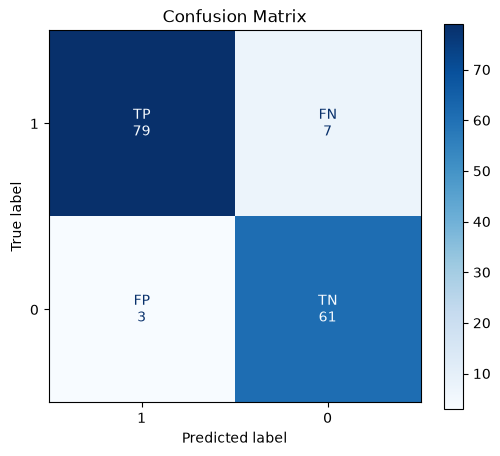

In [11]:
fig = create_mock_classification_problem(n_classes=2, random_state=115)
fig.savefig("./beamer/images/confusion_matrix_binary.png")


--- Multiclass Metrics ---
Overall Accuracy: 0.8267


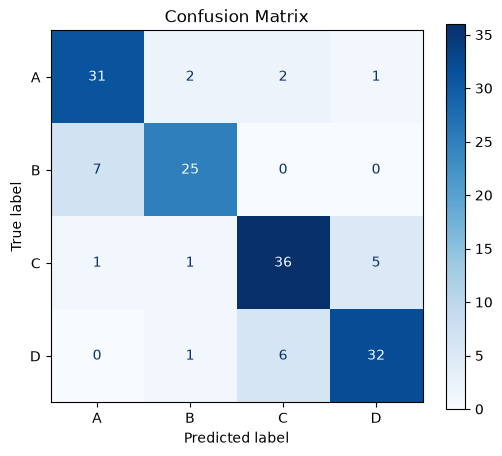

In [12]:
fig = create_mock_classification_problem(n_classes=4, random_state=115)
fig.savefig("./beamer/images/confusion_matrix_multi_class.png")


--- Classification Metrics ---
Accuracy:    0.9950
Precision:   0.0000
Sensitivity: 0.0000 (Recall)
Specificity: 1.0000
NPV:         0.9950


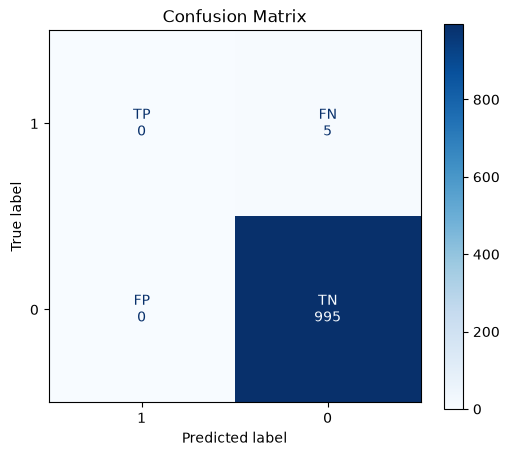

In [25]:
fig = create_mock_classification_problem(custom_matrix=[[0, 5],
                                                        [0, 995]])
fig.savefig("./beamer/images/confusion_matrix_imbalance.png")

In [ ]:
fig = create_mock_classification_problem(custom_matrix=[[9, 5],
                                                        [1, 985]])
fig.savefig("./beamer/images/confusion_matrix_imbalance.png")